# 01c – Hypothesis: NYC Citi Bike

**Worked on by:** Andreas Schellekens (test of the pre-registered hypotheses H1 and H4)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant). All findings and decisions were reviewed by the team; we must be able to explain every cell ourselves.

## 1. What we test, and why this way

`01b_eda_patterns.ipynb` ended with four candidate hypotheses (01b, section 6.2). The team chose:

- **H1 (main hypothesis): rain reduces casual trips relatively more than member trips.**
- **Daily demand** (the number of trips per day) as the prediction target for the models. That makes **H4** relevant as well: *weather and calendar predict daily demand better than the calendar alone*. If H4 were false, a demand model would not need weather data, and the deployment could not be built around a weather forecast.

The hypotheses were found by exploring **all** the data, so testing them on the same data would prove little: a pattern that was noticed in the data will of course be "significant" in that data. That is why 01b fixed the test and the rejection criterion of each hypothesis **before** this notebook, and why we test on a period that the fitted models have not seen:

| Period | Days | Role |
|---|---|---|
| discovery: 1 June 2013 - 31 December 2023 | about 3,870 | where the hypotheses come from; models are fitted here (H4) or estimated for comparison (H1) |
| hold-out: 1 January 2024 - 31 August 2026 | 974 | the test |

The criteria, copied from 01b section 6.2:

- **H1** is rejected if, on the hold-out period, the interaction user type x precipitation class for **heavy and very heavy** rain is not negative (for casual riders compared with members) or its 95% interval includes 0.
- **H4** is rejected if the weather model is not more accurate on the hold-out days (paired comparison of the daily errors).

H2 (holidays) and H3 (electric bikes and distance) stay as findings of 01b; they are not tested here.

## 2. Setup

The same libraries, plot style, DuckDB views and cleaning rules as 01b (01b section 1). The weather file is downloaded by 01b; if it is missing it is downloaded here in the same way.

In [1]:
import os
import time
import urllib.request
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pandas.tseries.holiday import USFederalHolidayCalendar

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
USER_COLOURS = {"member": BLUE, "casual": ORANGE}

DATA_DIR = Path("Data")
PARQUET_DIR = DATA_DIR / "parquet" / "trips"
WEATHER_FILE = DATA_DIR / "weather" / "USW00094728.csv"
WEATHER_URL = ("https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/"
               "USW00094728.csv")
FIRST_DAY, LAST_DAY = "2013-06-01", "2026-08-31"
DISCOVERY_END, HOLDOUT_START = "2023-12-31", "2024-01-01"

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute("INSTALL icu; LOAD icu")

CORRECTED_DURATION = """
    CASE WHEN source_format <> 'new' THEN tripduration_s
         ELSE date_diff('millisecond', timezone('America/New_York', started_at),
                                       timezone('America/New_York', ended_at)) / 1000.0
              + CASE WHEN ended_at < started_at THEN 3600 ELSE 0 END
    END
"""
NON_PUBLIC = ("'^(NYCBS Depot|NYCBS Test|8D |Kiosk in a box|Mobile 01|GOW Tech Shop|Shop Morgan|Lab - NYC|"
              "Prototype Lab|LA Metro Demo|MTL-)'")
REMOVE_RULES = f"""
    duration > 24 * 3600
    OR regexp_matches(coalesce(start_station_name, ''), {NON_PUBLIC})
    OR regexp_matches(coalesce(end_station_name, ''), {NON_PUBLIC})
    OR (start_station_id = end_station_id AND duration < 180)
"""
con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM read_parquet('{PARQUET_DIR.as_posix()}/*.parquet')")
con.execute(f"""
    CREATE OR REPLACE VIEW clean_trips AS
    SELECT * FROM (SELECT *, {CORRECTED_DURATION} AS duration FROM trips) WHERE NOT ({REMOVE_RULES})
""")
print("DuckDB", duckdb.__version__, "- views trips and clean_trips are ready")

DuckDB 1.5.6 - views trips and clean_trips are ready


## 3. The daily data

One row per day with the cleaned trips per user type and the weather, built exactly as in 01b section 2: the precipitation classes (dry 0 mm, light up to 2.5 mm, moderate 2.5-10 mm, heavy 10-25 mm, very heavy over 25 mm), snow on the ground, the federal holidays and the other days of the Christmas week (01b section 3.1).

In [2]:
if not WEATHER_FILE.exists():
    WEATHER_FILE.parent.mkdir(parents=True, exist_ok=True)
    temporary = WEATHER_FILE.with_suffix(".csv.part")
    urllib.request.urlretrieve(WEATHER_URL, temporary)
    os.replace(temporary, WEATHER_FILE)

raw = pd.read_csv(WEATHER_FILE, usecols=["DATE", "PRCP", "SNWD", "TMAX"], parse_dates=["DATE"], low_memory=False)
raw = raw[(raw.DATE >= FIRST_DAY) & (raw.DATE <= LAST_DAY)].set_index("DATE")
all_days = pd.date_range(FIRST_DAY, LAST_DAY, freq="D")
days = pd.DataFrame({"tmax_c": raw.TMAX / 10, "precipitation_mm": raw.PRCP / 10,
                     "snow_depth_mm": raw.SNWD}).reindex(all_days)

start = time.time()
per_user = con.sql("""
    SELECT CAST(started_at AS DATE) AS day, coalesce(user_type, 'unknown') AS user_type, count(*) AS trips
    FROM clean_trips WHERE started_at >= DATE '2013-06-01' GROUP BY ALL
""").df()
per_user["day"] = pd.to_datetime(per_user.day)
counts = per_user.pivot_table(index="day", columns="user_type", values="trips", aggfunc="sum").reindex(all_days)
days = days.join(counts.fillna(0).astype(int))
days["total"] = days[["member", "casual", "unknown"]].sum(axis=1)

PRECIPITATION_CLASSES = ["dry", "light", "moderate", "heavy", "very heavy"]
days["precipitation"] = pd.cut(days.precipitation_mm, [-0.1, 0, 2.5, 10, 25, np.inf], labels=PRECIPITATION_CLASSES)
days["snow_on_ground"] = (days.snow_depth_mm > 0).astype(int)
holidays = USFederalHolidayCalendar().holidays(FIRST_DAY, LAST_DAY)
month_day = days.index.strftime("%m-%d")
days["holiday"] = days.index.isin(holidays).astype(int)
days["christmas_week"] = (((month_day >= "12-24") | (month_day <= "01-01")) & (days.holiday == 0)).astype(int)
days["weekday"] = days.index.dayofweek
days["month"] = days.index.month
days["year_month"] = days.index.strftime("%Y-%m")
days["period"] = np.where(days.index <= DISCOVERY_END, "discovery", "hold-out")
print(f"{len(days):,} days, {days.total.sum():,} trips (built in {time.time() - start:.0f} s)")
days.groupby("period").agg(days=("total", "size"), trips=("total", "sum"), heavy_rain_days=(
    "precipitation", lambda p: int((p == "heavy").sum())), very_heavy_rain_days=(
    "precipitation", lambda p: int((p == "very heavy").sum())))

4,840 days, 321,939,739 trips (built in 100 s)


,days,trips,heavy_rain_days,very_heavy_rain_days
period,,,,
discovery,3866,202258675,309,140
hold-out,974,119681064,59,29


The hold-out period has 974 days with about 120 million trips, and enough rainy days to test H1: dozens of heavy and very heavy rain days (table above). The 10 days without trips (snowstorms, 01b section 2.3) are left out of the log models below, because the logarithm of 0 does not exist; one of them (23 February 2026) falls in the hold-out period.

## 4. H1: casual riders are put off more by rain

### 4.1 The model

We stack the data: **two rows per day**, one with the member trips and one with the casual trips. One log-linear model is fitted to both, as pre-registered, with:

- the weather terms of 01b (maximum temperature and its square, precipitation class, snow on the ground), the weekday and the month of every year (`year_month`), **each allowed to differ per user type**. Members and casual riders have opposite weekday patterns (casual riders +84% on Saturday, members -22%, 01b section 3.1) and grew at different rates, so one shared set of weekday and month terms would be wrong for both groups. A version with shared terms follows in 4.4 as a robustness check.
- the **interaction user type x precipitation class**. With members as the reference group, the interaction for, say, heavy rain is the difference between the casual and the member rain effect on the log scale. A negative value means that heavy rain costs casual riders a larger share of their trips than members. This is the number H1 is about.

The two rows of the same day share the same weather and the same unknown events, so their errors are correlated, and neighbouring days are correlated too. The standard errors therefore use Newey-West (HAC) with up to 7 days of correlation, applied to the **sum per day** of both rows (statsmodels' `hac-groupsum`), so that a day counts as one unit.

In [3]:
stacked = (days[days.total > 0]
           .melt(id_vars=["tmax_c", "precipitation", "snow_on_ground", "weekday", "year_month", "period"],
                 value_vars=["member", "casual"], var_name="user_type", value_name="trips", ignore_index=False)
           .rename_axis("day").reset_index().sort_values(["day", "user_type"]).reset_index(drop=True))
stacked = stacked[stacked.trips > 0]

H1_FORMULA = ("np.log(trips) ~ C(user_type, Treatment('member')) * (tmax_c + I(tmax_c ** 2) + C(precipitation)"
              " + snow_on_ground + C(weekday)) + C(user_type, Treatment('member')):C(year_month)")
INTERACTION = "C(user_type, Treatment('member'))[T.casual]:C(precipitation)[T.{}]"


def fit_h1(data, formula=H1_FORMULA):
    """Stacked log-linear model; HAC standard errors on the per-day sums of both rows."""
    data = data.reset_index(drop=True)
    day_number = data.day.factorize()[0]
    return smf.ols(formula, data=data).fit(cov_type="hac-groupsum", cov_kwds={"time": day_number, "maxlags": 7})


h1_models = {period: fit_h1(stacked[stacked.period == period]) for period in ("discovery", "hold-out")}
for period, model in h1_models.items():
    print(f"{period:>9}: {int(model.nobs):,} rows ({int(model.nobs) // 2:,} days), R-squared {model.rsquared:.3f}")

discovery: 7,714 rows (3,857 days), R-squared 0.956
 hold-out: 1,946 rows (973 days), R-squared 0.964


### 4.2 The interaction per precipitation class

The table shows the interaction for every precipitation class in both periods: the coefficient, its 95% interval, the p-value, and the same number as a percentage (`exp(coefficient) - 1`): how much lower the casual trips are, relative to the member trips, on such a day compared with a dry day.

In [4]:
rows = []
for period, model in h1_models.items():
    ci = model.conf_int()
    for precipitation in PRECIPITATION_CLASSES[1:]:
        term = INTERACTION.format(precipitation)
        rows.append({"period": period, "precipitation": precipitation,
                     "interaction": model.params[term], "ci_low": ci.loc[term, 0], "ci_high": ci.loc[term, 1],
                     "p_value": model.pvalues[term],
                     "casual_vs_member_pct": 100 * (np.exp(model.params[term]) - 1)})
interactions = pd.DataFrame(rows)
interactions.round({"interaction": 3, "ci_low": 3, "ci_high": 3, "casual_vs_member_pct": 1})

,period,precipitation,interaction,ci_low,ci_high,p_value,casual_vs_member_pct
0,discovery,light,-0.086,-0.121,-0.051,1.517448e-06,-8.2
1,discovery,moderate,-0.209,-0.246,-0.172,2.622197e-28,-18.9
2,discovery,heavy,-0.287,-0.335,-0.239,1.220016e-31,-25.0
3,discovery,very heavy,-0.500,-0.580,-0.420,1.144787e-34,-39.4
4,hold-out,light,-0.040,-0.068,-0.013,3.644293e-03,-4.0
5,hold-out,moderate,-0.118,-0.146,-0.089,4.759074e-16,-11.1
6,hold-out,heavy,-0.142,-0.188,-0.096,1.808394e-09,-13.2
7,hold-out,very heavy,-0.222,-0.278,-0.166,7.898841e-15,-19.9


The relative numbers are easier to read per group: the chart shows the rain effect for members (the precipitation coefficient) and for casual riders (precipitation coefficient + interaction), each with its 95% interval, in the hold-out period. The interval of a sum of two coefficients is computed with `t_test`, which takes their covariance into account.

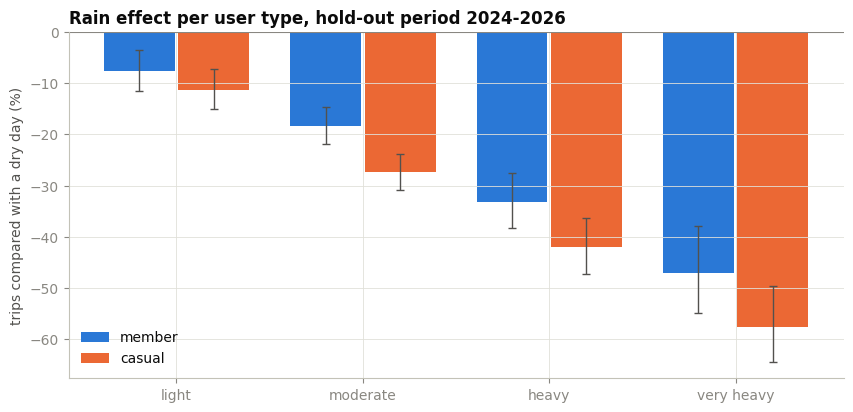

user_type,casual,member
precipitation,,
light,-11.3,-7.6
moderate,-27.4,-18.4
heavy,-42.0,-33.1
very heavy,-57.6,-47.1


In [5]:
holdout = h1_models["hold-out"]
effect_rows = []
for precipitation in PRECIPITATION_CLASSES[1:]:
    main = f"C(precipitation)[T.{precipitation}]"
    for user_type, terms in [("member", [main]), ("casual", [main, INTERACTION.format(precipitation)])]:
        contrast = np.zeros(len(holdout.params))
        for term in terms:
            contrast[holdout.params.index.get_loc(term)] = 1
        test = holdout.t_test(contrast)
        low, high = test.conf_int()[0]
        effect_rows.append({"precipitation": precipitation, "user_type": user_type,
                            "effect_pct": 100 * (np.exp(test.effect[0]) - 1),
                            "ci_low_pct": 100 * (np.exp(low) - 1), "ci_high_pct": 100 * (np.exp(high) - 1)})
group_effects = pd.DataFrame(effect_rows)

positions = np.arange(len(PRECIPITATION_CLASSES) - 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
for offset, user_type in [(-0.2, "member"), (0.2, "casual")]:
    part = group_effects[group_effects.user_type == user_type]
    errors = np.vstack([part.effect_pct - part.ci_low_pct, part.ci_high_pct - part.effect_pct])
    ax.bar(positions + offset, part.effect_pct, width=0.38, color=USER_COLOURS[user_type], label=user_type,
           yerr=errors, error_kw={"ecolor": INK_SECONDARY, "elinewidth": 1, "capsize": 3})
ax.set_xticks(positions, PRECIPITATION_CLASSES[1:])
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_ylabel("trips compared with a dry day (%)")
ax.set_title("Rain effect per user type, hold-out period 2024-2026", loc="left")
ax.legend(loc="lower left", frameon=False)
plt.show()
group_effects.pivot(index="precipitation", columns="user_type", values="effect_pct").reindex(
    PRECIPITATION_CLASSES[1:]).round(1)

### 4.3 Decision

The criterion: H1 is rejected if, in the hold-out period, the interaction for heavy and very heavy rain is not negative or its 95% interval includes 0.

In [6]:
decision = interactions[(interactions.period == "hold-out")
                        & interactions.precipitation.isin(["heavy", "very heavy"])].copy()
decision["negative_and_interval_below_0"] = decision.ci_high < 0
print(decision[["precipitation", "interaction", "ci_low", "ci_high", "negative_and_interval_below_0"]]
      .round(3).to_string(index=False))
print("\nH1 is", "NOT rejected" if decision.negative_and_interval_below_0.all() else "REJECTED")

precipitation  interaction  ci_low  ci_high  negative_and_interval_below_0
        heavy       -0.142  -0.188   -0.096                           True
   very heavy       -0.222  -0.278   -0.166                           True

H1 is NOT rejected


**H1 is not rejected.** In the hold-out period the interaction is negative for heavy rain (-0.142, 95% interval -0.188 to -0.096) and for very heavy rain (-0.222, interval -0.278 to -0.166), and neither interval comes near 0. On a heavy-rain day the casual trips are about 13% lower, relative to the member trips, than on a dry day; on a very heavy rain day about 20% lower. In the chart: heavy rain costs members 33% of their trips and casual riders 42%, very heavy rain 47% against 58%. The same direction holds for light and moderate rain.

Two honest remarks:

- The difference is **about half as large** in the hold-out period as in the discovery period (heavy rain: -0.14 against -0.29; very heavy: -0.22 against -0.50). The hypothesis holds, but the gap between the groups is shrinking. That fits 01b section 3, where casual riders became more like members since 2020 (more rush-hour trips, shorter trips).
- A test that fails to reject is not a proof. It means that data the hypothesis had not seen behaved as predicted, which is the strongest support an observational dataset can give. The data does not say **why** casual riders are more sensitive; leisure trips that can be postponed is a plausible explanation, not a tested one.
- The result depends on how the model is specified; 4.4 shows how much.

### 4.4 Robustness: does the decision depend on the specification?

The pre-registration described "one log-linear model with the weather, weekday and month terms and a user type x precipitation class interaction". It did not say whether those terms are shared by both user types or differ per type. In 4.1 we let them all differ per type, which is the stacked version of the separate models per user type that 01b used (01b sections 2.6 and 3.1). The simplest reading shares them. We fit five specifications on the hold-out period, from fully shared to fully separate, and report the two interactions of the criterion for each, with the R-squared and the spread of the residuals (how much each model leaves unexplained).

In [7]:
U = "C(user_type, Treatment('member'))"
WEATHER_SHARED = "tmax_c + I(tmax_c ** 2) + snow_on_ground"
SPECIFICATIONS = {
    "1 all shared": f"np.log(trips) ~ {U} * C(precipitation) + {WEATHER_SHARED} + C(weekday) + C(year_month)",
    "2 weekday per type": f"np.log(trips) ~ {U} * C(precipitation) + {WEATHER_SHARED} + {U} * C(weekday) + C(year_month)",
    "3 month level per type": f"np.log(trips) ~ {U} * C(precipitation) + {WEATHER_SHARED} + C(weekday) + {U}:C(year_month)",
    "4 weekday and month per type": (f"np.log(trips) ~ {U} * C(precipitation) + {WEATHER_SHARED} + {U} * C(weekday)"
                                     f" + {U}:C(year_month)"),
    "5 everything per type (4.1)": H1_FORMULA,
}
rows = []
for name, formula in SPECIFICATIONS.items():
    model = fit_h1(stacked[stacked.period == "hold-out"], formula)
    ci = model.conf_int()
    row = {"specification": name, "r_squared": model.rsquared, "residual_sd": np.sqrt(model.scale)}
    for precipitation in ("heavy", "very heavy"):
        term = INTERACTION.format(precipitation)
        row[f"{precipitation} (95% interval)"] = (f"{model.params[term]:.3f} ({ci.loc[term, 0]:.3f} to "
                                                  f"{ci.loc[term, 1]:.3f})")
        row[f"{precipitation} below 0"] = ci.loc[term, 1] < 0
    rows.append(row)
pd.DataFrame(rows).round(3)

,specification,r_squared,residual_sd,heavy (95% interval),heavy below 0,very heavy (95% interval),very heavy below 0
0,1 all shared,0.919,0.312,-0.094 (-0.220 to 0.031),False,-0.163 (-0.328 to 0.003),False
1,2 weekday per type,0.933,0.285,-0.132 (-0.246 to -0.018),True,-0.196 (-0.338 to -0.054),True
2,3 month level per type,0.947,0.255,-0.118 (-0.208 to -0.027),True,-0.223 (-0.346 to -0.101),True
3,4 weekday and month per type,0.960,0.221,-0.155 (-0.218 to -0.092),True,-0.255 (-0.329 to -0.180),True
4,5 everything per type (4.1),0.964,0.212,-0.142 (-0.188 to -0.096),True,-0.222 (-0.278 to -0.166),True


The interaction is **negative in all five specifications**, so the direction of the effect does not depend on the model. Its **significance** does:

- In specifications 2 to 5 both intervals lie below 0: as soon as the two user types may differ in their weekday pattern **or** in their monthly level, H1 is supported.
- In specification 1, where members and casual riders must share one weekday pattern and one monthly level, the intervals widen and include 0 (heavy rain -0.094, interval -0.220 to 0.031; very heavy -0.163, interval -0.328 to 0.003). Under that reading of the pre-registration, H1 would be rejected.

Specification 1 is clearly misspecified: it forces a weekend pattern on both groups that is wrong for both (01b section 3.1: Saturday +84% for casual riders, -22% for members). Its residual spread is about half as large again as that of the full model (0.31 against 0.21 on the log scale), and those large weekday errors are what make its intervals wide. We therefore keep specification 5 as the test, chosen because it mirrors the separate models of 01b, but we report the result with this qualification: **the evidence for H1 is consistent in direction, and it is significant only when the model allows for the different weekly and monthly patterns of the two groups.**

## 5. H4: weather adds predictive value to a demand model

### 5.1 Two models, fitted on the discovery period

Both models predict the logarithm of the total trips per day and are fitted **only on the discovery period** (up to 31 December 2023):

- **calendar model:** a linear trend (years since June 2013), the month, the weekday, federal holidays and the Christmas week;
- **weather model:** the same terms plus maximum temperature and its square, precipitation class and snow on the ground.

Unlike in 01b, there are no `year_month` terms: a forecast for a new month cannot know that month's level, so the trend and the month of the year have to do that job. Both models then predict every day of the hold-out period, and we compare the prediction with the actual trips.

In [8]:
days["years"] = (days.index - pd.Timestamp(FIRST_DAY)).days / 365.25
CALENDAR = "np.log(total) ~ years + C(month) + C(weekday) + holiday + christmas_week"
WEATHER = CALENDAR + " + tmax_c + I(tmax_c ** 2) + C(precipitation) + snow_on_ground"
train = days[(days.period == "discovery") & (days.total > 0)]
test = days[(days.period == "hold-out") & (days.total > 0)].copy()

errors = {}
for name, formula in [("calendar", CALENDAR), ("weather", WEATHER)]:
    model = smf.ols(formula, data=train).fit()
    test[f"pred_{name}"] = np.exp(model.predict(test))
    errors[name] = (test[f"pred_{name}"] - test.total).abs() / test.total * 100  # absolute percentage error
    print(f"{name:>8} model: R-squared on the discovery period {model.rsquared:.3f}")

summary = pd.DataFrame({
    "MAPE_pct": {name: e.mean() for name, e in errors.items()},
    "median_APE_pct": {name: e.median() for name, e in errors.items()},
    "share_within_20pct": {name: (e <= 20).mean() * 100 for name, e in errors.items()},
}).round(1)
summary

calendar model: R-squared on the discovery period 0.696
 weather model: R-squared on the discovery period 0.849


,MAPE_pct,median_APE_pct,share_within_20pct
calendar,30.8,15.6,59.6
weather,16.2,11.4,74.4


### 5.2 Paired comparison and decision

Both models predict the same 973 hold-out days, so we compare them **day by day**: for every day the error of the calendar model minus the error of the weather model. The mean of these differences with a 95% interval (HAC, as before) shows whether the weather model is more accurate. H4 is rejected if it is not.

In [9]:
difference = errors["calendar"] - errors["weather"]
fit = smf.ols("y ~ 1", data=pd.DataFrame({"y": difference})).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
low, high = fit.conf_int().loc["Intercept"]
print(f"Calendar error minus weather error: {fit.params['Intercept']:.1f} percentage points "
      f"(95% interval {low:.1f} to {high:.1f}); the weather model is better on {(difference > 0).mean():.0%} of the days")
print("H4 is", "NOT rejected" if low > 0 else "REJECTED")
print("\nMAPE per year of the hold-out period:")
print(pd.DataFrame(errors).groupby(test.index.year).mean().round(1).to_string())

Calendar error minus weather error: 14.6 percentage points (95% interval 7.5 to 21.6); the weather model is better on 61% of the days
H4 is NOT rejected

MAPE per year of the hold-out period:
      calendar  weather
2024      22.4     12.3
2025      23.3     15.1
2026      54.7     23.8


**H4 is not rejected.** On the hold-out days the weather model has a mean absolute percentage error (MAPE) of 16.2% against 30.8% for the calendar model; the paired difference is 14.6 percentage points with a 95% interval of 7.5 to 21.6, well above 0. The weather model is more accurate in every year of the hold-out period. The weather model is not better on every single day (on about 61% of the days); on days with ordinary weather both models are about equally good, and the weather model wins big on the days with rain, snow or cold.

The errors are largest in 2026, mainly because of the cold and snowy weeks of January and February 2026 (01b section 2.3): on days with only a few thousand trips a small absolute error is a large percentage. The median error, which is less sensitive to those days, is 11.4% for the weather model against 15.6% for the calendar model.

The chart shows the actual trips of 2025 with both predictions.

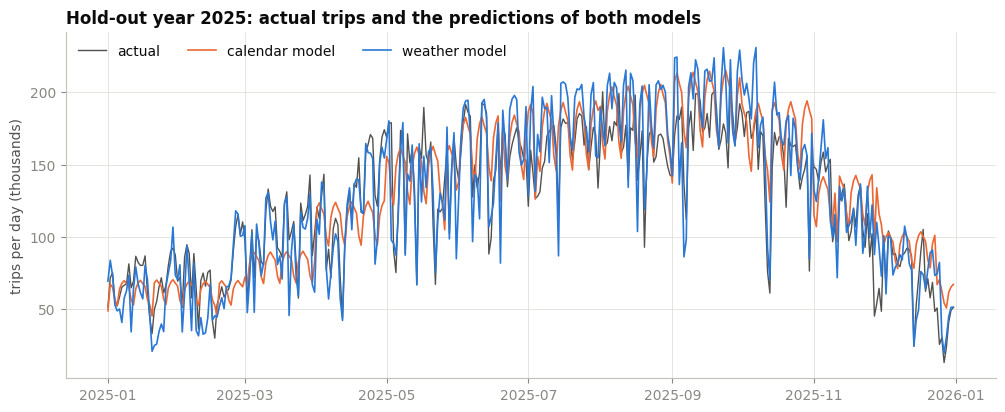

In [10]:
year_2025 = test.index.year == 2025
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test.index[year_2025], test.total[year_2025] / 1e3, color=INK_SECONDARY, linewidth=1, label="actual")
ax.plot(test.index[year_2025], test.pred_calendar[year_2025] / 1e3, color=ORANGE, linewidth=1.2,
        label="calendar model")
ax.plot(test.index[year_2025], test.pred_weather[year_2025] / 1e3, color=BLUE, linewidth=1.2,
        label="weather model")
ax.set_ylabel("trips per day (thousands)")
ax.set_title("Hold-out year 2025: actual trips and the predictions of both models", loc="left")
ax.legend(loc="upper left", frameon=False, ncol=3)
plt.show()

The calendar model can only draw a seasonal curve with weekday wiggles; it misses every rainy or cold day. The weather model follows most of the dips, and sometimes predicts a dip that is deeper than what happened (rain that fell at night or on a quiet day costs fewer trips than the daily total suggests). Both models sit a little too high in the warm months of 2025; the linear trend fitted up to 2023 cannot know that growth slowed in 2025 (01a section 6). That is a lesson for the models: the trend needs care, for example by training on recent years or by letting the model learn the level from the most recent data.

## 6. Conclusion and what it means for the models

| Hypothesis | Test (pre-registered in 01b section 6.2) | Result |
|---|---|---|
| **H1** rain reduces casual trips relatively more than member trips | interaction user type x precipitation on the hold-out period 2024-2026 | **not rejected**: heavy rain -0.142 (95% interval -0.188 to -0.096), very heavy -0.222 (-0.278 to -0.166); negative in all five specifications, significant in four (not when both groups must share one weekday and month pattern); the gap is about half as large as before 2024 |
| **H4** weather and calendar predict daily demand better than the calendar alone | models fitted up to 2023, paired comparison of the daily errors on 2024-2026 | **not rejected**: MAPE 16.2% against 30.8%, difference 14.6 points (7.5 to 21.6) |

For the daily-demand model this means:

1. **Weather features are essential**: maximum temperature (non-linear), precipitation (as amount or class), snow on the ground; wind helped a little in 01b section 2.7. The deployment can take them from a weather forecast.
2. **Calendar features**: weekday, month or season, federal holidays and the Christmas week.
3. **The trend is the hardest part**: the system grew fast and unevenly (COVID-19, the electric bike). A time-based split is required, never a random one: a random split would let the model see the days around every test day.
4. **Proposed split for the data-preparation notebook** (to be decided with the team): train on June 2013 to December 2023, validate on 2024 (for model choices, as with the mushrooms), test once on January 2025 to August 2026. Note that the EDA has looked at all years, so the test period is unseen by the models, not by us.
5. Because H1 holds, it can be worth predicting members and casual riders separately (two targets that react differently to the weather) and adding them up.